## 1. Install

In [1]:
#pip install geopandas

## 2. Imports

In [2]:
import pandas as pd
import geopandas as gpd
%matplotlib inline

## 3.Verify

In [3]:
print("Pandas:", pd.__version__)
print("Geopandas:", gpd.__version__)

Pandas: 3.0.3
Geopandas: 1.1.4


## 4. Create Data


In [4]:
data = {
    "city":["Chennai","Bengaluru","Hyderabad"],
    "latitude":[13.0827,12.9716,17.3850],
    "longitude":[80.2707,77.5946,78.4867],
    "population":[7000000,13000000,10000000]
}
df = pd.DataFrame(data)

In [5]:
df

,city,latitude,longitude,population
0,Chennai,13.0827,80.2707,7000000
1,Bengaluru,12.9716,77.5946,13000000
2,Hyderabad,17.3850,78.4867,10000000


## 5. Geo points

In [6]:
# convert log/ latit to pint geometry
geometry = gpd.points_from_xy(df['longitude'], df['latitude'])

## 6. GeoDataFrame


In [7]:
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs = "EPSG:4326")

In [8]:
# EPSG:European Petroleum Survey Group
# CRS: Coordinate Reference System

# 4326=> unique code for WGS 84 => 1984

# WGS: World Geodetic system

## 7. Inspect

In [9]:
# important Properties
gdf.geometry # geo column


0    POINT (80.2707 13.0827)
1    POINT (77.5946 12.9716)
2     POINT (78.4867 17.385)
Name: geometry, dtype: geometry

In [10]:
gdf.geom_type # point, polygon, line


0    Point
1    Point
2    Point
dtype: str

In [11]:
gdf.crs # EPSG


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [12]:
gdf.total_bounds # overall bounding box



array([77.5946, 12.9716, 80.2707, 17.385 ])

In [13]:
gdf.geometry.x # longi


0    80.2707
1    77.5946
2    78.4867
dtype: float64

In [14]:
gdf.geometry.y # latit

0    13.0827
1    12.9716
2    17.3850
dtype: float64

## 8. Filter / Extract data

In [15]:
gdf[gdf['population']>8000000]

,city,latitude,longitude,population,geometry
1,Bengaluru,12.9716,77.5946,13000000,POINT (77.5946 12.9716)
2,Hyderabad,17.3850,78.4867,10000000,POINT (78.4867 17.385)


In [16]:
gdf.sort_values("population", ascending=False)

,city,latitude,longitude,population,geometry
1,Bengaluru,12.9716,77.5946,13000000,POINT (77.5946 12.9716)
2,Hyderabad,17.3850,78.4867,10000000,POINT (78.4867 17.385)
0,Chennai,13.0827,80.2707,7000000,POINT (80.2707 13.0827)


In [17]:
gdf[(gdf['population']>8000000)& (gdf['population']<12000000)]

,city,latitude,longitude,population,geometry
2,Hyderabad,17.385,78.4867,10000000,POINT (78.4867 17.385)


In [18]:
gdf['population']

0     7000000
1    13000000
2    10000000
Name: population, dtype: int64

In [19]:
# multi columns
gdf[['city','population']]

,city,population
0,Chennai,7000000
1,Bengaluru,13000000
2,Hyderabad,10000000


In [20]:
# Statistics
gdf['population'].mean()

np.float64(10000000.0)

In [21]:
gdf['population'].min()

np.int64(7000000)

In [22]:
gdf['population'].describe()

count           3.0
mean     10000000.0
std       3000000.0
min       7000000.0
25%       8500000.0
50%      10000000.0
75%      11500000.0
max      13000000.0
Name: population, dtype: float64

In [23]:
gdf.describe()

,latitude,longitude,population
count,3.000000,3.000000,3.0
mean,14.479767,78.784000,10000000.0
std,2.516619,1.362596,3000000.0
min,12.971600,77.594600,7000000.0
25%,13.027150,78.040650,8500000.0
50%,13.082700,78.486700,10000000.0
75%,15.233850,79.378700,11500000.0
max,17.385000,80.270700,13000000.0


## 9.Basic Maps

<Axes: >

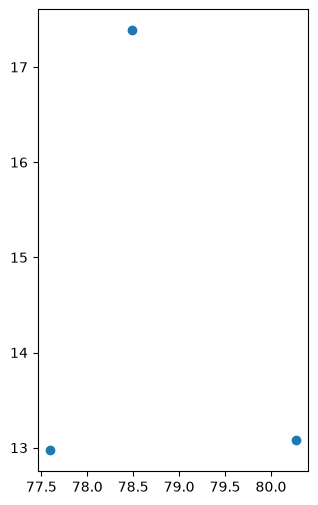

In [24]:
gdf.plot(figsize = (8,6))

<Axes: >

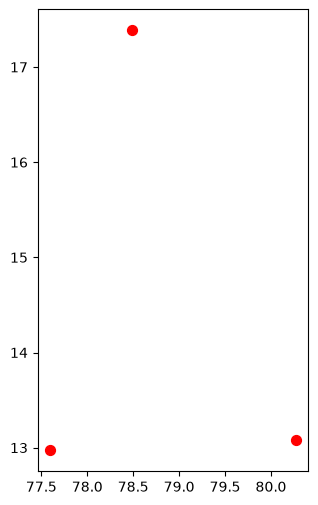

In [25]:
gdf.plot(color = 'red', markersize = 50,figsize = (6,6))

<Axes: >

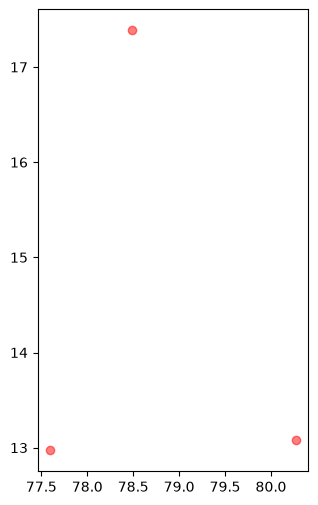

In [26]:
gdf.plot(color = 'red', alpha = 0.5,figsize = (8,6))

## 10. Thematic maps

<Axes: >

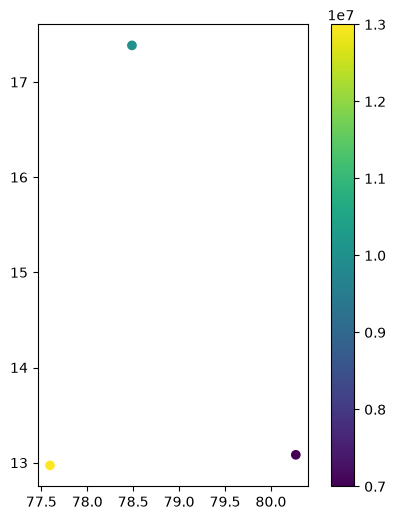

In [27]:
gdf.plot(column = 'population', legend = True, cmap = 'viridis',figsize = (6,6))

<Axes: >

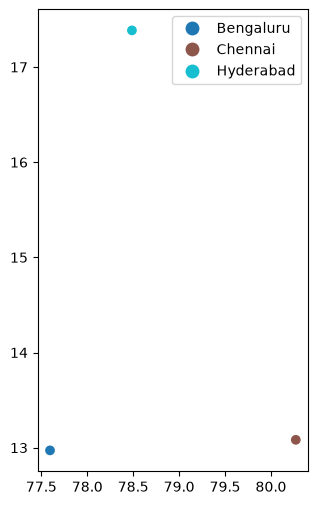

In [28]:
# diff color based on category
gdf.plot(column = 'city', legend = True, categorical = True,figsize = (8,6))

<Axes: >

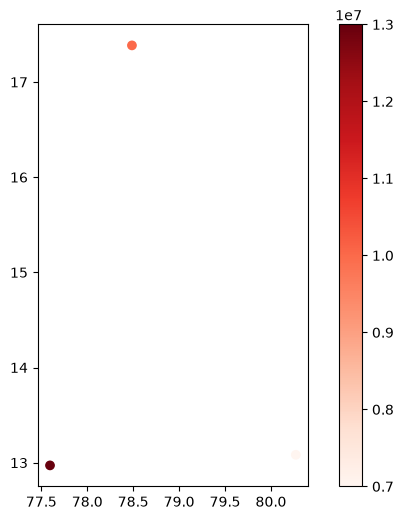

In [29]:
# diff color scheme
gdf.plot(column = 'population', legend = True, cmap = 'Reds',figsize = (8,6))

<Axes: >

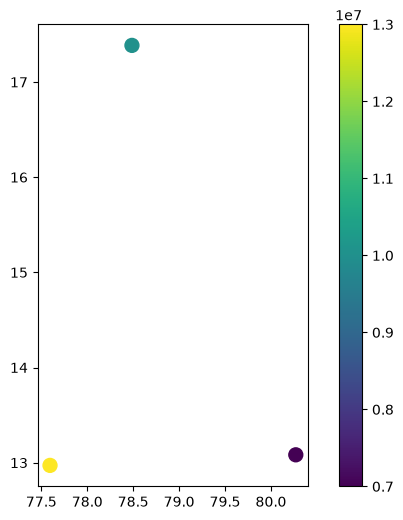

In [30]:
# control points
gdf.plot(column = 'population', legend = True, markersize = 100,figsize = (8,6))

<Axes: >

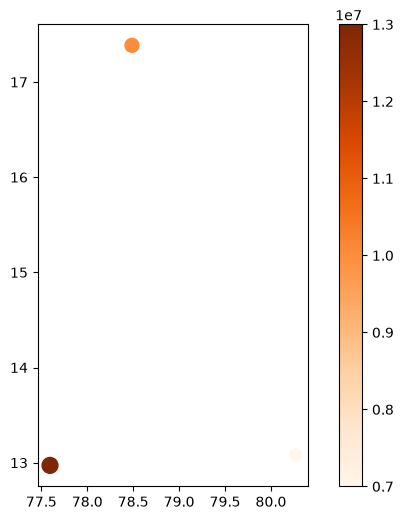

In [31]:
# control points => depends on population
gdf.plot(column = 'population', legend = True, 
         markersize = gdf['population']/100000,
         cmap = "Oranges",figsize = (8,6))


Text(0.5, 1.0, 'Population by City')

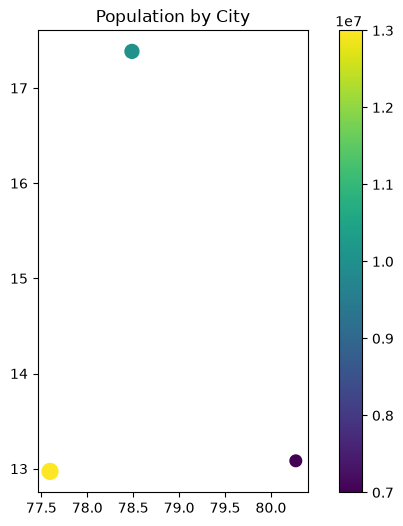

In [33]:
ax = gdf.plot(column = 'population', legend = True, 
         markersize = gdf['population']/100000,
         cmap = "viridis",figsize = (8,6))
ax.set_title("Population by City")

## let's Practice


In [34]:
data_1= {
"city": ["Mumbai", "Delhi", "Kolkata"],
"latitude": [19.0760, 28.6139, 22.5726],
"longitude": [72.8777, 77.2090, 88.3639],
"population": [12400000, 11000000, 4500000]
}

In [35]:
# create dataframe with the data
df_1 = pd.DataFrame(data_1)

In [36]:
df_1

,city,latitude,longitude,population
0,Mumbai,19.0760,72.8777,12400000
1,Delhi,28.6139,77.2090,11000000
2,Kolkata,22.5726,88.3639,4500000


In [37]:
df_1.shape

(3, 4)

In [38]:
df_1.head(2)

,city,latitude,longitude,population
0,Mumbai,19.0760,72.8777,12400000
1,Delhi,28.6139,77.2090,11000000


In [39]:
geometry = gpd.points_from_xy(df_1['longitude'], df_1['latitude'])

In [40]:
# geoDataFrame
gdf_1 = gpd.GeoDataFrame(df_1, geometry=geometry, crs = "EPSG:4326")

In [41]:
print(gdf_1.geometry)

0     POINT (72.8777 19.076)
1     POINT (77.209 28.6139)
2    POINT (88.3639 22.5726)
Name: geometry, dtype: geometry


In [42]:
print(gdf_1.geom_type)

0    Point
1    Point
2    Point
dtype: str


In [43]:
# CRS => GeoDataFrame
print(gdf_1.crs)

EPSG:4326


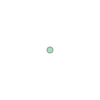

In [44]:
# first row of Geodataframe
gdf_1.geometry.iloc[0]

In [45]:
print(gdf_1.geometry.iloc[0])

POINT (72.8777 19.076)


In [47]:
print(gdf_1.geometry.iloc[0].x) # longitu

72.8777


In [48]:
print(gdf_1.geometry.iloc[0].y) # latitude / y coordinat

19.076


In [49]:
# total bounding box of all geometries in gdf
print(gdf_1.total_bounds)

[72.8777 19.076  88.3639 28.6139]


In [50]:
# city and population
print(gdf_1[['city', 'population']]) 

      city  population
0   Mumbai    12400000
1    Delhi    11000000
2  Kolkata     4500000


In [53]:
# populatio > 11 M
print(gdf_1[gdf_1['population']>11000000]) 

     city  latitude  longitude  population                geometry
0  Mumbai    19.076    72.8777    12400000  POINT (72.8777 19.076)


In [54]:
# sort city by population in desce
gdf_1.sort_values("population", ascending=False)

,city,latitude,longitude,population,geometry
0,Mumbai,19.0760,72.8777,12400000,POINT (72.8777 19.076)
1,Delhi,28.6139,77.2090,11000000,POINT (77.209 28.6139)
2,Kolkata,22.5726,88.3639,4500000,POINT (88.3639 22.5726)


In [55]:
# add a col pop_million
gdf_1['pop_million'] = gdf_1['population']/1000000
gdf_1

,city,latitude,longitude,population,geometry,pop_million
0,Mumbai,19.0760,72.8777,12400000,POINT (72.8777 19.076),12.4
1,Delhi,28.6139,77.2090,11000000,POINT (77.209 28.6139),11.0
2,Kolkata,22.5726,88.3639,4500000,POINT (88.3639 22.5726),4.5


In [56]:
# add latit_band => greater >20 Norther else its sourthern
gdf_1['lati_band'] = gdf_1['latitude'].apply(lambda x: "Northern" if x>=20 else "Sourthern")
gdf_1

,city,latitude,longitude,population,geometry,pop_million,lati_band
0,Mumbai,19.0760,72.8777,12400000,POINT (72.8777 19.076),12.4,Sourthern
1,Delhi,28.6139,77.2090,11000000,POINT (77.209 28.6139),11.0,Northern
2,Kolkata,22.5726,88.3639,4500000,POINT (88.3639 22.5726),4.5,Northern


In [57]:
# find the northernmost city based on the geo y.coordinate and store it as northernmost
northernmost = gdf_1.loc[gdf_1.geometry.y.idxmax(), "city"]

In [58]:
# find the southernmost city based on the geo y.coordinate and store it as southernmost
southernmost = gdf_1.loc[gdf_1.geometry.y.idxmin(), "city"]

In [59]:
print(northernmost,southernmost)

Delhi Mumbai


<Axes: >

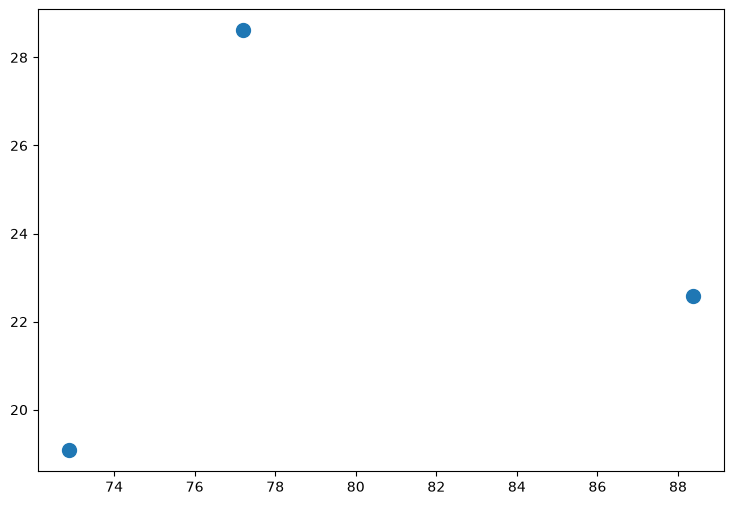

In [61]:
# basic plot
gdf_1.plot(figsize = (10,6), markersize = 100)

<Axes: >

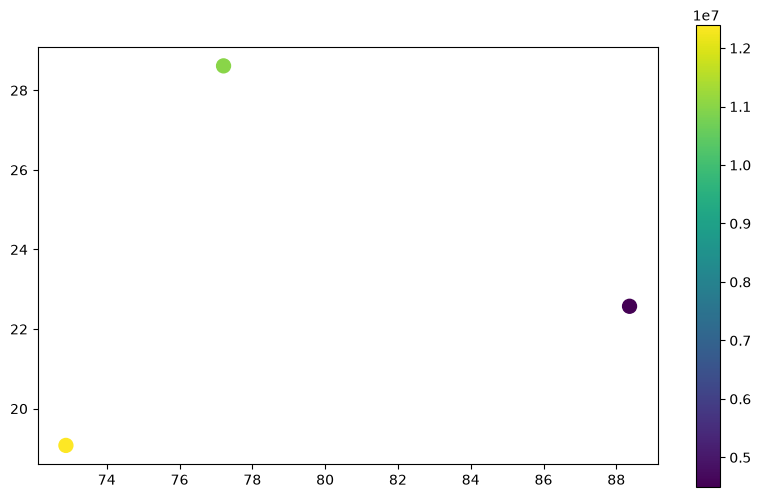

In [63]:
# thematic map
gdf_1.plot(column = "population", legend = True, figsize = (10,6), markersize = 100)